In [1]:
import pandas as pd
import numpy as np

In [2]:
df_rank_sum_merged = pd.read_csv('/data/project/yeonu/consensus/celltype_rank_sum_merged.csv')
print(df_rank_sum_merged.shape)
print(df_rank_sum_merged.head())

(5835, 9)
     gene  rank_sum_in_myeloid  rank_sum_in_eptheilal  rank_sum_in_plasma  \
0    A1BG               9977.0                    NaN                 NaN   
1    A1CF                  NaN                 1278.0                 NaN   
2     A2M                  5.0                    NaN                 NaN   
3  A4GALT                  NaN                    NaN                 NaN   
4    AAK1               4060.0                13585.0                 NaN   

   rank_sum_in_neutrophil  rank_sum_in_stromal  rank_sum_in_b_cell  \
0                     NaN                  NaN                 NaN   
1                     NaN                  NaN                 NaN   
2                     NaN               6301.0                 NaN   
3                     NaN              14343.0                 NaN   
4                     NaN               4926.0                 NaN   

   rank_sum_in_mast consensus  
0               NaN  MSI_high  
1               NaN  MSS_high  
2         

# <font color="red">**Specific** <font color="blue">**Myeloid** 

In [3]:
# myeloid의 threshold 값 (예시: 5000, 필요에 따라 조정)
myeloid_threshold = 1000

# 비교할 나머지 cell type들의 컬럼명을 추출 (myeloid 제외)
other_cols = [col for col in df_rank_sum_merged.columns 
              if col.startswith('rank_sum_in_') and col != 'rank_sum_in_myeloid']

# NaN 값은 비교 시 문제가 될 수 있으므로, 다른 cell type 컬럼의 NaN은 매우 큰 값으로 대체합니다.
df_temp = df_rank_sum_merged.copy()
df_temp[other_cols] = df_temp[other_cols].fillna(float('28476'))

# 조건 1: myeloid의 rank sum 값이 threshold 보다 작아야 함.
condition1 = df_temp['rank_sum_in_myeloid'] < myeloid_threshold

# 조건 2: myeloid의 rank sum 값이 다른 모든 cell type의 rank sum 값보다 작아야 함.
condition2 = df_temp['rank_sum_in_myeloid'] < df_temp[other_cols].min(axis=1)

# 두 조건을 모두 만족하는 gene 선택
df_myeloid_specific = df_temp[condition1 & condition2]

# 결과 확인
print(df_myeloid_specific.shape)
print(df_myeloid_specific.head())


(397, 9)
      gene  rank_sum_in_myeloid  rank_sum_in_eptheilal  rank_sum_in_plasma  \
2      A2M                  5.0                28476.0             28476.0   
8    ABCA1                194.0                28476.0             28476.0   
17  ABHD12                349.0                12388.0             28476.0   
30    ABL2                  5.0                28476.0             28476.0   
41   ACAP2                  5.0                12489.0             28476.0   

    rank_sum_in_neutrophil  rank_sum_in_stromal  rank_sum_in_b_cell  \
2                  28476.0               6301.0             28476.0   
8                  28476.0               4899.0             28476.0   
17                 28476.0              28476.0             28476.0   
30                 28476.0                351.0             28476.0   
41                   817.0               8008.0              1399.0   

    rank_sum_in_mast consensus  
2            28476.0  MSS_high  
8             2021.0  MSS_hig

In [4]:
df_myeloid_specific

,gene,rank_sum_in_myeloid,rank_sum_in_eptheilal,rank_sum_in_plasma,rank_sum_in_neutrophil,rank_sum_in_stromal,rank_sum_in_b_cell,rank_sum_in_mast,consensus
2,A2M,5.0,28476.0,28476.0,28476.0,6301.0,28476.0,28476.0,MSS_high
8,ABCA1,194.0,28476.0,28476.0,28476.0,4899.0,28476.0,2021.0,MSS_high
17,ABHD12,349.0,12388.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high
30,ABL2,5.0,28476.0,28476.0,28476.0,351.0,28476.0,28476.0,MSS_high
41,ACAP2,5.0,12489.0,28476.0,817.0,8008.0,1399.0,2248.0,MSI_high
...,...,...,...,...,...,...,...,...,...
5698,XBP1,468.0,8696.0,1976.0,28476.0,6355.0,28476.0,1409.0,MSS_high
5700,XIST,208.0,28476.0,28476.0,28476.0,2480.0,28476.0,28476.0,MSS_high
5731,YWHAH,337.0,13741.0,28476.0,28476.0,7495.0,28476.0,28476.0,MSS_high
5765,ZFAND5,314.0,12782.0,3013.0,28476.0,10021.0,2544.0,3503.0,MSS_high


In [5]:
# rank_sum_in_myeloid 컬럼을 기준으로 오름차순 정렬
df_myeloid_specific_sorted = df_myeloid_specific.sort_values(by='rank_sum_in_myeloid')

# 정렬된 결과 확인
df_myeloid_specific_sorted.head(20)

,gene,rank_sum_in_myeloid,rank_sum_in_eptheilal,rank_sum_in_plasma,rank_sum_in_neutrophil,rank_sum_in_stromal,rank_sum_in_b_cell,rank_sum_in_mast,consensus
180,ALOX5AP,5.0,28476.0,28476.0,1354.0,28476.0,1883.0,3131.0,MSS_high
168,ALCAM,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high
145,AHNAK,5.0,6280.0,2762.0,28476.0,6625.0,5402.0,3448.0,MSI_high
2,A2M,5.0,28476.0,28476.0,28476.0,6301.0,28476.0,28476.0,MSS_high
5800,ZNF331,5.0,28476.0,28476.0,28476.0,28476.0,83.0,3378.0,MSS_high
273,ARF5,5.0,4289.0,28476.0,28476.0,1195.0,514.0,28476.0,MSI_high
287,ARHGAP18,5.0,10813.0,28476.0,28476.0,7854.0,28476.0,4111.0,MSS_high
334,ARL4C,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high
194,ANKHD1,5.0,5312.0,28476.0,28476.0,12936.0,28476.0,28476.0,MSI_high
591,C1QA,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high


In [6]:
print(len(df_myeloid_specific_sorted[df_myeloid_specific_sorted["rank_sum_in_myeloid"] == 5]))
df_myeloid_specific_sorted[df_myeloid_specific_sorted["rank_sum_in_myeloid"] == 5]

136


,gene,rank_sum_in_myeloid,rank_sum_in_eptheilal,rank_sum_in_plasma,rank_sum_in_neutrophil,rank_sum_in_stromal,rank_sum_in_b_cell,rank_sum_in_mast,consensus
180,ALOX5AP,5.0,28476.0,28476.0,1354.0,28476.0,1883.0,3131.0,MSS_high
168,ALCAM,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high
145,AHNAK,5.0,6280.0,2762.0,28476.0,6625.0,5402.0,3448.0,MSI_high
2,A2M,5.0,28476.0,28476.0,28476.0,6301.0,28476.0,28476.0,MSS_high
5800,ZNF331,5.0,28476.0,28476.0,28476.0,28476.0,83.0,3378.0,MSS_high
...,...,...,...,...,...,...,...,...,...
5375,TRAPPC1,5.0,28476.0,28476.0,28476.0,265.0,28476.0,28476.0,MSS_high
5304,TNFSF10,5.0,10875.0,28476.0,28476.0,12126.0,28476.0,3988.0,MSI_high
5306,TNFSF13,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSI_high
5288,TNFAIP3,5.0,28476.0,1881.0,1393.0,15945.0,28476.0,2731.0,MSS_high


In [7]:
# consensus 컬럼이 'MSS_high'인 데이터프레임
df_myeloid_specific_MSS = df_myeloid_specific_sorted[df_myeloid_specific_sorted['consensus'] == 'MSS_high']

# consensus 컬럼이 'MSI_high'인 데이터프레임
df_myeloid_specific_MSI = df_myeloid_specific_sorted[df_myeloid_specific_sorted['consensus'] == 'MSI_high']


In [8]:
df_myeloid_specific_MSS

,gene,rank_sum_in_myeloid,rank_sum_in_eptheilal,rank_sum_in_plasma,rank_sum_in_neutrophil,rank_sum_in_stromal,rank_sum_in_b_cell,rank_sum_in_mast,consensus
180,ALOX5AP,5.0,28476.0,28476.0,1354.0,28476.0,1883.0,3131.0,MSS_high
168,ALCAM,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high
2,A2M,5.0,28476.0,28476.0,28476.0,6301.0,28476.0,28476.0,MSS_high
5800,ZNF331,5.0,28476.0,28476.0,28476.0,28476.0,83.0,3378.0,MSS_high
287,ARHGAP18,5.0,10813.0,28476.0,28476.0,7854.0,28476.0,4111.0,MSS_high
...,...,...,...,...,...,...,...,...,...
1105,COX7B,798.0,9587.0,28476.0,28476.0,15583.0,4679.0,4722.0,MSS_high
4073,RAB7A,808.0,6270.0,28476.0,1669.0,11760.0,3874.0,2389.0,MSS_high
5004,SUB1,828.0,12233.0,2442.0,28476.0,16220.0,5484.0,4011.0,MSS_high
4331,RPL38,952.0,8759.0,2218.0,28476.0,7109.0,1033.0,1264.0,MSS_high


In [9]:
df_myeloid_specific_MSI

,gene,rank_sum_in_myeloid,rank_sum_in_eptheilal,rank_sum_in_plasma,rank_sum_in_neutrophil,rank_sum_in_stromal,rank_sum_in_b_cell,rank_sum_in_mast,consensus
145,AHNAK,5.0,6280.0,2762.0,28476.0,6625.0,5402.0,3448.0,MSI_high
273,ARF5,5.0,4289.0,28476.0,28476.0,1195.0,514.0,28476.0,MSI_high
194,ANKHD1,5.0,5312.0,28476.0,28476.0,12936.0,28476.0,28476.0,MSI_high
588,C19orf38,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSI_high
585,C17orf49,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSI_high
...,...,...,...,...,...,...,...,...,...
2283,ICAM3,347.0,28476.0,2043.0,28476.0,28476.0,4589.0,28476.0,MSI_high
829,CDC42EP3,366.0,28476.0,28476.0,438.0,1810.0,28476.0,376.0,MSI_high
4549,SERPINA1,380.0,28476.0,28476.0,1661.0,28476.0,28476.0,28476.0,MSI_high
975,CLEC12A,383.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSI_high


In [10]:
print(len(df_myeloid_specific_MSS[df_myeloid_specific_MSS["rank_sum_in_myeloid"] == 5]))
df_myeloid_specific_MSS_5 = df_myeloid_specific_MSS[df_myeloid_specific_MSS["rank_sum_in_myeloid"] == 5]
df_myeloid_specific_MSS_5

95


,gene,rank_sum_in_myeloid,rank_sum_in_eptheilal,rank_sum_in_plasma,rank_sum_in_neutrophil,rank_sum_in_stromal,rank_sum_in_b_cell,rank_sum_in_mast,consensus
180,ALOX5AP,5.0,28476.0,28476.0,1354.0,28476.0,1883.0,3131.0,MSS_high
168,ALCAM,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high
2,A2M,5.0,28476.0,28476.0,28476.0,6301.0,28476.0,28476.0,MSS_high
5800,ZNF331,5.0,28476.0,28476.0,28476.0,28476.0,83.0,3378.0,MSS_high
287,ARHGAP18,5.0,10813.0,28476.0,28476.0,7854.0,28476.0,4111.0,MSS_high
...,...,...,...,...,...,...,...,...,...
2179,HLA-DQA2,5.0,28476.0,28476.0,28476.0,28476.0,803.0,28476.0,MSS_high
5614,VEGFA,5.0,3825.0,28476.0,28476.0,28476.0,28476.0,590.0,MSS_high
370,ATF3,5.0,707.0,63.0,28476.0,4182.0,28476.0,3161.0,MSS_high
5375,TRAPPC1,5.0,28476.0,28476.0,28476.0,265.0,28476.0,28476.0,MSS_high


In [11]:
# print(len(df_myeloid_specific_MSI[df_myeloid_specific_MSI["rank_sum_in_myeloid"] == 5]))
# df_myeloid_specific_MSI_5 = df_myeloid_specific_MSI[df_myeloid_specific_MSI["rank_sum_in_myeloid"] == 5]
# df_myeloid_specific_MSI_5

### <font color="blue">**Boxplot**</font>

In [12]:
# ▶ Load expression matrix
expr_path = "/nas/arpa_h_repository/public_data/CRC_Atlas_1/CRC-Atlas-Split/crc-atlas/Deg_data/filtered_count_matrix/filtered_myeloid_count.csv"
expr_df = pd.read_csv(expr_path, index_col=0)
# ▶ Load metadata
meta_path = "/nas/arpa_h_repository/public_data/CRC_Atlas_1/CRC-Atlas-Split/crc-atlas/Deg_data/cellinfo_DA/cellinfo_DA_myeloid_cell_consensus.csv"
meta_df = pd.read_csv(meta_path)

In [13]:
df_myeloid_specific_MSS_5

,gene,rank_sum_in_myeloid,rank_sum_in_eptheilal,rank_sum_in_plasma,rank_sum_in_neutrophil,rank_sum_in_stromal,rank_sum_in_b_cell,rank_sum_in_mast,consensus
180,ALOX5AP,5.0,28476.0,28476.0,1354.0,28476.0,1883.0,3131.0,MSS_high
168,ALCAM,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high
2,A2M,5.0,28476.0,28476.0,28476.0,6301.0,28476.0,28476.0,MSS_high
5800,ZNF331,5.0,28476.0,28476.0,28476.0,28476.0,83.0,3378.0,MSS_high
287,ARHGAP18,5.0,10813.0,28476.0,28476.0,7854.0,28476.0,4111.0,MSS_high
...,...,...,...,...,...,...,...,...,...
2179,HLA-DQA2,5.0,28476.0,28476.0,28476.0,28476.0,803.0,28476.0,MSS_high
5614,VEGFA,5.0,3825.0,28476.0,28476.0,28476.0,28476.0,590.0,MSS_high
370,ATF3,5.0,707.0,63.0,28476.0,4182.0,28476.0,3161.0,MSS_high
5375,TRAPPC1,5.0,28476.0,28476.0,28476.0,265.0,28476.0,28476.0,MSS_high


In [14]:
# 1. 다른 cell type의 rank_sum 평균 계산
other_cols = ['rank_sum_in_eptheilal', 'rank_sum_in_plasma',
              'rank_sum_in_neutrophil', 'rank_sum_in_stromal',
              'rank_sum_in_b_cell', 'rank_sum_in_mast']

df_myeloid_specific_MSS_5['avg_other'] = df_myeloid_specific_MSS_5[other_cols].mean(axis=1)

# 2. myeloid와 다른 cell type 간의 차이(diff) 계산
df_myeloid_specific_MSS_5['diff'] = df_myeloid_specific_MSS_5['avg_other'] - df_myeloid_specific_MSS_5['rank_sum_in_myeloid']

# 3. diff 값 기준으로 내림차순 정렬 (필요한 경우)
df_sorted = df_myeloid_specific_MSS_5.sort_values(by='diff', ascending=False)

/tmp/ipykernel_900625/2646541975.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_myeloid_specific_MSS_5['avg_other'] = df_myeloid_specific_MSS_5[other_cols].mean(axis=1)
/tmp/ipykernel_900625/2646541975.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_myeloid_specific_MSS_5['diff'] = df_myeloid_specific_MSS_5['avg_other'] - df_myeloid_specific_MSS_5['rank_sum_in_myeloid']


In [15]:
df_sorted.head(20)

,gene,rank_sum_in_myeloid,rank_sum_in_eptheilal,rank_sum_in_plasma,rank_sum_in_neutrophil,rank_sum_in_stromal,rank_sum_in_b_cell,rank_sum_in_mast,consensus,avg_other,diff
168,ALCAM,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high,28476.0,28471.0
334,ARL4C,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high,28476.0,28471.0
591,C1QA,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high,28476.0,28471.0
254,APOC1,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high,28476.0,28471.0
592,C1QB,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high,28476.0,28471.0
757,CD163,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high,28476.0,28471.0
4709,SLC40A1,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high,28476.0,28471.0
607,C3AR1,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high,28476.0,28471.0
2754,MAF,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high,28476.0,28471.0
1217,CXCL3,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high,28476.0,28471.0


In [16]:
print(df_sorted.shape)
df_sorted.head(20)

(95, 11)


,gene,rank_sum_in_myeloid,rank_sum_in_eptheilal,rank_sum_in_plasma,rank_sum_in_neutrophil,rank_sum_in_stromal,rank_sum_in_b_cell,rank_sum_in_mast,consensus,avg_other,diff
168,ALCAM,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high,28476.0,28471.0
334,ARL4C,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high,28476.0,28471.0
591,C1QA,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high,28476.0,28471.0
254,APOC1,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high,28476.0,28471.0
592,C1QB,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high,28476.0,28471.0
757,CD163,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high,28476.0,28471.0
4709,SLC40A1,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high,28476.0,28471.0
607,C3AR1,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high,28476.0,28471.0
2754,MAF,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high,28476.0,28471.0
1217,CXCL3,5.0,28476.0,28476.0,28476.0,28476.0,28476.0,28476.0,MSS_high,28476.0,28471.0


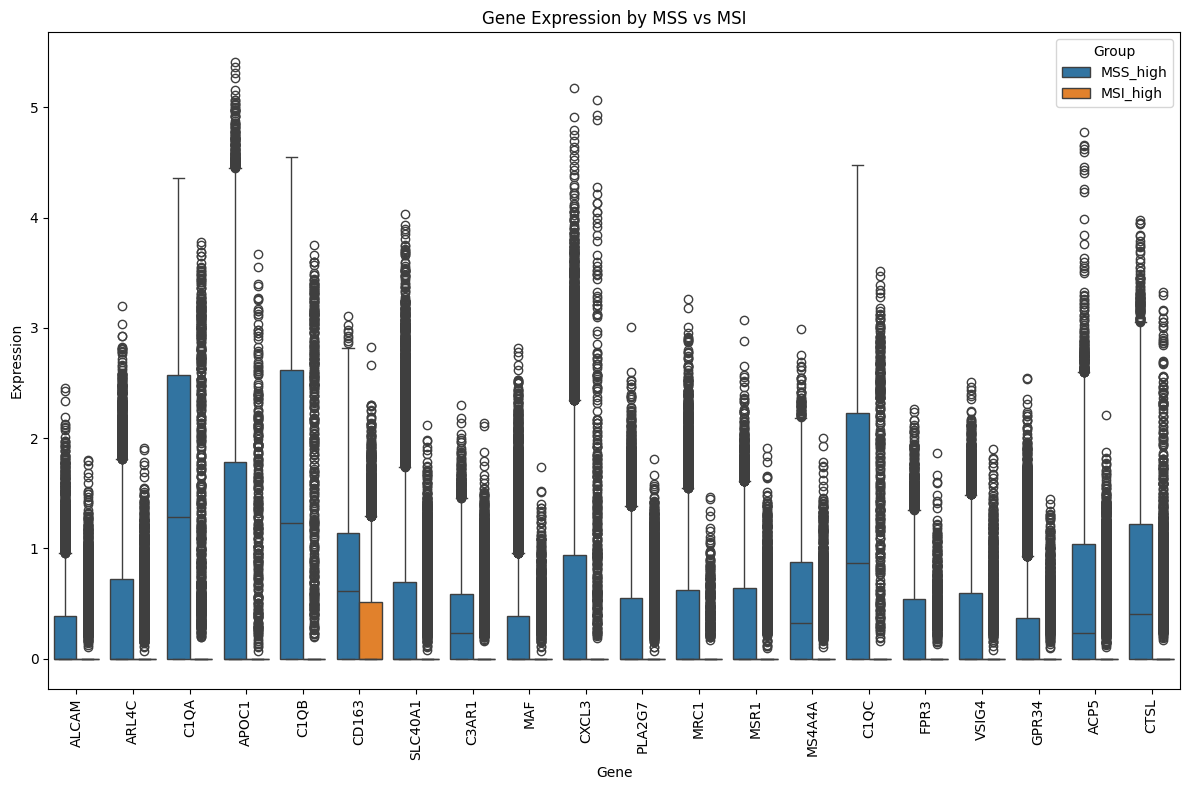

In [17]:
# gene_list = df_sorted['gene'].tolist()
gene_list = df_sorted.head(20)['gene'].tolist()

# 상위 유전자 리스트를 이용해 발현 데이터 서브셋 준비 (세포×유전자 형태로 전치)
expr = expr_df.loc[gene_list].T

# 메타데이터와 병합하여 각 세포에 그룹 정보 추가
expr = expr.merge(meta_df[['cell_name', 'Group']], left_index=True, right_on='cell_name')

# 필요한 라이브러리 임포트
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 형태를 long format으로 변환하여 melt 함수 적용
expr_melted = expr.melt(id_vars='Group', value_vars=gene_list, 
                        var_name='Gene', value_name='Expression')

# boxplot 그리기
plt.figure(figsize=(12, 8))
sns.boxplot(data=expr_melted, x='Gene', y='Expression', hue='Group')
plt.xticks(rotation=90)
plt.title('Gene Expression by MSS vs MSI')
plt.tight_layout()
plt.show()
